<a href="https://colab.research.google.com/github/janani-tamilarasan/AI-Resource/blob/main/Machine%20Learning/logistic_regression/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression

### 1. Business Requriements
Insurance claim cases(1300+)

**Target Variable:** ATTORNEY
1 = Hired attorney
0 = Did not hire attorney

**Input Variables:**
CLMSEX
CLMINSUR
SEATBELT
CLMAGE
LOSS

Expectation:
1.   Predict claiments will hire attonomy
2.   LiUnder wthat type of customer more likely hire attonomy



In [286]:
### Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,roc_auc_score
from pickle import dump,load



### 2. Data Collection/import data set

In [287]:
claimants_data = pd.read_csv(
    "https://raw.githubusercontent.com/janani-tamilarasan/AI-Resource/main/Machine%20Learning/logistic_regression/claimants.csv"
)

claimants_data.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


### 3. Data Understanding

NOTE:
WE ave null values

In [288]:
print(claimants_data.shape)
print(claimants_data.info())
print(claimants_data.isna().sum())
print(claimants_data.dtypes)

(1340, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CASENUM   1340 non-null   int64  
 1   ATTORNEY  1340 non-null   int64  
 2   CLMSEX    1328 non-null   float64
 3   CLMINSUR  1299 non-null   float64
 4   SEATBELT  1292 non-null   float64
 5   CLMAGE    1151 non-null   float64
 6   LOSS      1340 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 73.4 KB
None
CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64
CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object


### 4. Data PReparaion, cleaning

In [289]:
claimants_data.dropna(inplace=True)
print(claimants_data.isna().sum())


CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64


#### Exploratory Data Analysis

<Axes: xlabel='ATTORNEY', ylabel='count'>

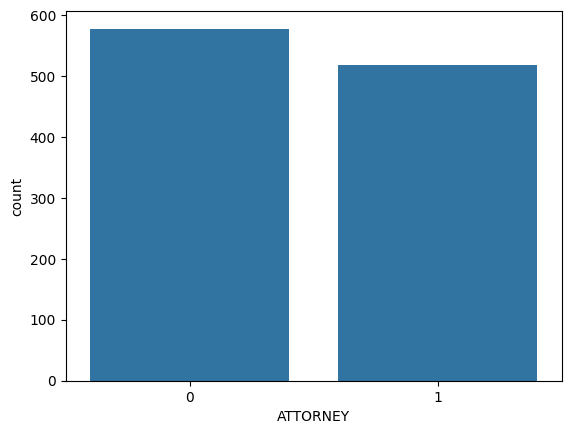

In [290]:

sns.countplot(x="ATTORNEY", data=claimants_data)

###  5. Train test split and Data Split


In [291]:
X = claimants_data.drop(['CASENUM', 'ATTORNEY'], axis= 1)
Y = claimants_data['ATTORNEY']

X_Train, X_Test, Y_Train, Y_Test = train_test_split(X,Y, test_size=0.20, random_state=64)

### 6. Model Building

In [292]:
logistic_model = LogisticRegression()


#### 7.  Model Training

In [293]:
logistic_model.fit(X_Train,Y_Train)

LogisticRegression()

### 8. Model Testing

In [294]:
Y_Pred = logistic_model.predict(X_Test)
Y_Pred

array([1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0])

### 9. Model Evaluation

#### 9.1 Confusion Matrix

[
  [TN, FP]
  [FN, TP]
]

In [295]:
#confusion_matrix

cm  = confusion_matrix(Y_Test, Y_Pred)
print(cm)

[[74 44]
 [27 75]]


#### 9.2 Accuracy - Out of all predictions, how many were correct?
Accuracy = (TP + TN) / Total

In [296]:
accuracy  = accuracy_score(Y_Test, Y_Pred)
print(accuracy)

0.6772727272727272


#### 9.3 Precision - Out of all predicted "Yes", how many were actually "Yes"?(Scalability)

Precision = TP / (TP + FP)


In [297]:
#precision1  = TP / (TP + FP)
#[[74 44]
 # [27 75]]

precision  = (75 / 119)
precision

0.6302521008403361

#### 9.4 Recall - Out of all actual "Yes", how many did we correctly identify?
Recall = TP / (TP + FN)

In [298]:
#recall1  =TP / (TP + FN)
#[[74 44]
 # [27 75]]

recall  = (75 / 102)
recall

0.7352941176470589

#### 9.5 F1 Score -  Balances Precision and Recall.
F1 = 2 × Precision × Recall
     ----------------------
     Precision + Recall

#### Classification Report

In [299]:
print(classification_report(Y_Test, Y_Pred))

              precision    recall  f1-score   support

           0       0.73      0.63      0.68       118
           1       0.63      0.74      0.68       102

    accuracy                           0.68       220
   macro avg       0.68      0.68      0.68       220
weighted avg       0.69      0.68      0.68       220



#### 9.6 ROC-AUC Score

In [300]:
Y_Prob = logistic_model.predict_proba(X_Test)


roc_auc_score(Y_Test, Y_Prob[:,1])

np.float64(0.7706879361914256)

### Model Deployment

In [301]:
dump(logistic_model,open("claimaints.pkl","wb"))

logistic_model_pkl = load(file = open("claimaints.pkl","rb"))
logistic_model_pkl.predict(X_Test)

array([1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0])